In [1]:
import numpy as np
import pandas as pd

from sympy.physics.quantum.density import entropy

np.random.seed(42)
n = 300

study_hours    = np.random.uniform(1, 10, n)
sleep_hours    = np.random.uniform(4, 9,  n)
practice_tests = np.random.randint(0, 6,  n)
attendance_pct = np.random.uniform(50, 100, n)

# Ground-truth decision rule (with realistic noise)
score = (
    0.35 * (study_hours / 10)    +
    0.25 * (sleep_hours / 9)     +
    0.25 * (practice_tests / 5) +
    0.15 * (attendance_pct / 100)
)
passed = (score + np.random.normal(0, 0.08, n) > 0.5).astype(int)

df = pd.DataFrame({
    'study_hours':    study_hours.round(1),
    'sleep_hours':    sleep_hours.round(1),
    'practice_tests': practice_tests,
    'attendance_pct': attendance_pct.round(1),
    'passed':         passed
})

print(df.head(8).to_string(index=False))
print(f"\nPass rate: {passed.mean():.1%} | Shape: {df.shape}")

 study_hours  sleep_hours  practice_tests  attendance_pct  passed
         4.4          4.3               4            78.3       1
         9.6          6.7               1            84.8       1
         7.6          6.7               3            96.1       1
         6.4          7.2               1            85.4       1
         2.4          7.6               4            57.6       1
         2.4          8.9               5            78.8       1
         1.5          6.6               4            80.3       1
         8.8          5.6               5            71.2       1

Pass rate: 77.0% | Shape: (300, 5)


In [2]:
np.random.random()

0.12020905537060844

In [3]:
df

,study_hours,sleep_hours,practice_tests,attendance_pct,passed
0,4.4,4.3,4,78.3,1
1,9.6,6.7,1,84.8,1
2,7.6,6.7,3,96.1,1
3,6.4,7.2,1,85.4,1
4,2.4,7.6,4,57.6,1
...,...,...,...,...,...
295,5.7,6.4,0,80.4,1
296,7.9,7.3,3,75.6,1
297,2.9,4.9,2,61.5,0
298,6.6,5.0,3,58.8,1


In [4]:
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
y = df["passed"]
x = df.drop("passed", axis=1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=20)
dt = DecisionTreeClassifier(criterion='entropy',random_state=20)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
print("Accuracy ", accuracy_score(y_test, y_pred))

Accuracy  0.8555555555555555


In [5]:
y_pred_train = dt.predict(x_train)
print(accuracy_score(y_train,y_pred_train))

1.0


In [6]:
tree_text = export_text(dt,feature_names=["study_hours", "sleep_hours", "practice_tests", "attendance_pct"])
print(tree_text)

|--- study_hours <= 4.85
|   |--- practice_tests <= 0.50
|   |   |--- class: 0
|   |--- practice_tests >  0.50
|   |   |--- practice_tests <= 4.50
|   |   |   |--- sleep_hours <= 6.55
|   |   |   |   |--- attendance_pct <= 91.45
|   |   |   |   |   |--- attendance_pct <= 81.50
|   |   |   |   |   |   |--- practice_tests <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- practice_tests >  1.50
|   |   |   |   |   |   |   |--- study_hours <= 3.40
|   |   |   |   |   |   |   |   |--- study_hours <= 1.85
|   |   |   |   |   |   |   |   |   |--- attendance_pct <= 60.80
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- attendance_pct >  60.80
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- study_hours >  1.85
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- study_hours >  3.40
|   |   |   |   |   |   |   |   |--- attendance_pct <= 67.65
|   |  

In [7]:
df.columns.values


<ArrowStringArray>
['study_hours', 'sleep_hours', 'practice_tests', 'attendance_pct', 'passed']
Length: 5, dtype: str

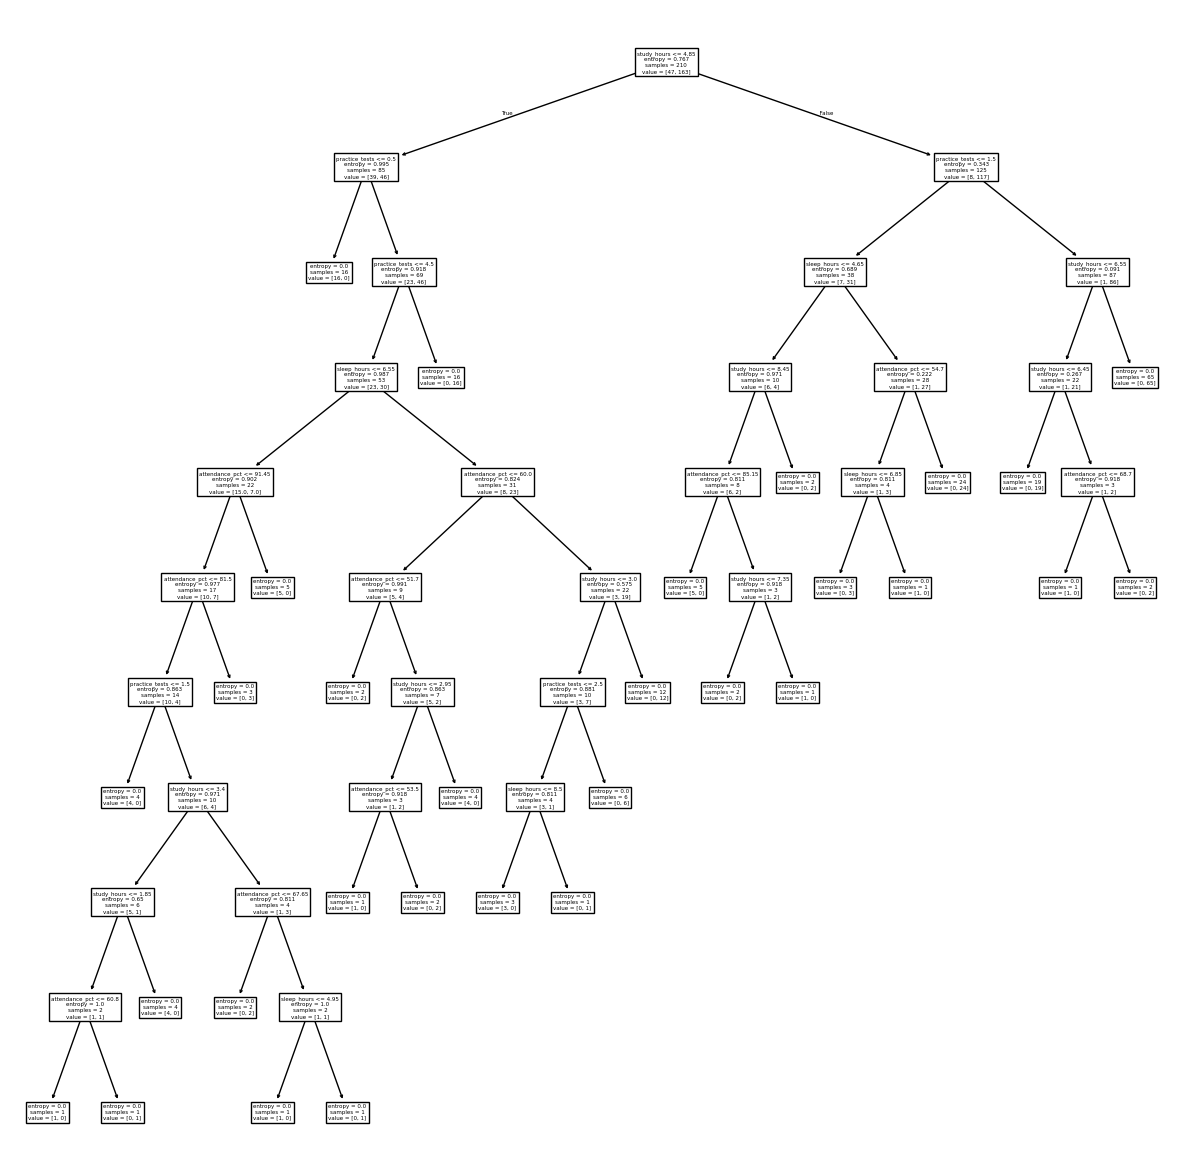

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
plot_tree(dt,feature_names=["study_hours", "sleep_hours", "practice_tests", "attendance_pct"])
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier, _forest
rf = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    random_state=20,
    max_depth=6,
    max_features='sqrt',
    n_jobs=-1,
    min_samples_split=5,
    min_samples_leaf=2,
)

In [10]:
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy ", accuracy_score(y_test, y_pred))
y_pred_train = rf.predict(x_train)
print(accuracy_score(y_train,y_pred_train))

Accuracy  0.9111111111111111
0.9666666666666667


In [12]:
print(confusion_matrix(y_test,y_pred))

[[18  4]
 [ 4 64]]


In [13]:
rf.feature_importances_

array([0.37916248, 0.18420312, 0.30054419, 0.13609021])

In [18]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators': [50,100,200,300],
    'max_depth' : [4,6,8,None],
    'min_samples_leaf' : [1,2,4],
    'max_features' : ['sqrt','log2'],
}
base = RandomForestClassifier(criterion="entropy",oob_score=True,random_state=20)
grid_search = GridSearchCV(base,params,cv = 5,scoring='accuracy',n_jobs=-1)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'n_estimators': 50}

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

# ── Realistic tumour features ────────────────────────
n = 200
# Class 0 = Benign, Class 1 = Malignant
benign_radius    = np.random.normal(12, 2.5,  n//2)
benign_texture   = np.random.normal(17, 3.0,  n//2)
malig_radius     = np.random.normal(19, 3.0,  n//2)
malig_texture    = np.random.normal(25, 3.5,  n//2)

X = np.vstack([
    np.column_stack([benign_radius, benign_texture]),
    np.column_stack([malig_radius,  malig_texture])
])
y = np.hstack([np.zeros(n//2), np.ones(n//2)]).astype(int)

df = pd.DataFrame(X, columns=['radius', 'texture'])
df['label'] = y
df['diagnosis'] = df['label'].map({0:'Benign', 1:'Malignant'})

# Scale features - CRITICAL for SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(df.describe().round(2))
print(f"\nClass distribution: {dict(pd.Series(y).value_counts())}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

       radius  texture  label
count  200.00   200.00  200.0
mean    15.47    21.22    0.5
std      4.67     5.12    0.5
min      5.45    11.24    0.0
25%     11.62    17.28    0.0
50%     14.79    21.49    0.5
75%     19.27    25.19    1.0
max     30.56    32.66    1.0

Class distribution: {0: np.int64(100), 1: np.int64(100)}
Train: 160 | Test: 40


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import (classification_report,
                               confusion_matrix,
                               roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Compare all four kernels ──────────────────────
kernels = {
    'linear':  SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'rbf':     SVC(kernel='rbf',    C=1.0, gamma='scale', probability=True, random_state=42),
    'poly':    SVC(kernel='poly',   C=1.0, degree=3,        probability=True, random_state=42),
    'sigmoid': SVC(kernel='sigmoid',C=1.0,                  probability=True, random_state=42),
}

print("KERNEL COMPARISON")
print("═"*65)
print(f"{'Kernel':12} {'Train Acc':>10} {'Test Acc':>10} {'ROC-AUC':>10} {'#SVs':>8}")
print("─"*65)

for name, clf in kernels.items():
    clf.fit(X_train, y_train)
    tr_acc = clf.score(X_train, y_train)
    te_acc = clf.score(X_test,  y_test)
    auc    = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    n_sv   = clf.n_support_.sum()
    print(f"{name:12} {tr_acc:>10.4f} {te_acc:>10.4f} {auc:>10.4f} {n_sv:>8}")

# ── 2. Best model: RBF SVM detailed report ──────────
best = SVC(kernel='rbf', C=10, gamma='scale',
           probability=True, random_state=42)
best.fit(X_train, y_train)
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]

print("\n\nDETAILED REPORT - RBF SVM (C=10)")
print("═"*50)
print(f"  Support vectors per class: {best.n_support_}")
print(f"  Total support vectors:     {best.n_support_.sum()}")
print(f"  Test accuracy:             {best.score(X_test, y_test):.4f}")
print(f"  ROC-AUC:                   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Benign','Malignant'])}")

KERNEL COMPARISON
═════════════════════════════════════════════════════════════════
Kernel        Train Acc   Test Acc    ROC-AUC     #SVs
─────────────────────────────────────────────────────────────────
linear           0.9812     0.9750     1.0000       16
rbf              0.9812     0.9750     1.0000       25
poly             0.9750     0.9500     0.9975       45
sigmoid          0.9812     0.9750     0.9975       20


DETAILED REPORT - RBF SVM (C=10)
══════════════════════════════════════════════════
  Support vectors per class: [6 8]
  Total support vectors:     14
  Test accuracy:             0.9750
  ROC-AUC:                   0.9900

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.98        20
   Malignant       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
}
gs = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best params:    {gs.best_params_}")
print(f"Best CV AUC:    {gs.best_score_:.4f}")
tuned = gs.best_estimator_
print(f"Test Accuracy:  {tuned.score(X_test, y_test):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, tuned.predict_proba(X_test)[:,1]):.4f}")

Best params:    {'C': 0.01, 'gamma': 'scale'}
Best CV AUC:    0.9984
Test Accuracy:  0.9750
Test ROC-AUC:   0.9975
